First 5 records:
  Protocol  Source_Port  Destination_Port  Packet_Length  Flow_Duration  \
0     HTTP        48629                21           1379           1923   
1     ICMP        57278                22           1164           1574   
2      TCP        41104                21            283           2342   
3     HTTP        39112                80            529           3343   
4     HTTP        14240                53             51           7090   

   Number_of_Packets  Network_Traffic Attack_Type  
0                 45             4358      Normal  
1                401            89535        DDoS  
2                247            77524      Normal  
3                104            98057      Normal  
4                 85             6698      Normal  

Dataset Shape:
(1000, 8)

Attack Distribution:
Attack_Type
Normal         738
Brute_Force    150
DoS             57
DDoS            55
Name: count, dtype: int64

Training samples: 800
Testing samples: 200

Random Forest

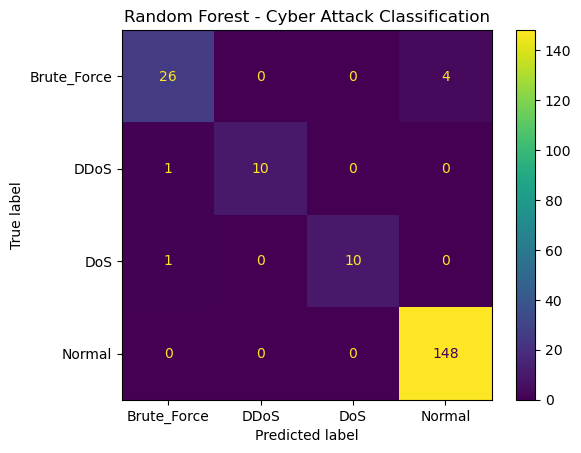


Feature Importance:
Number_of_Packets    0.369498
Destination_Port     0.217613
Flow_Duration        0.145074
Network_Traffic      0.116417
Source_Port          0.062383
Packet_Length        0.061709
Protocol_ICMP        0.008138
Protocol_UDP         0.007124
Protocol_TCP         0.007029
Protocol_HTTP        0.005014
dtype: float64


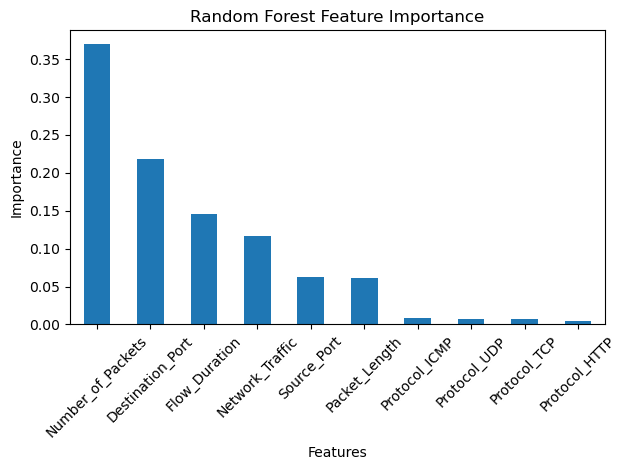

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Generate cybersecurity network traffic dataset

np.random.seed(42)
n = 1000

data = pd.DataFrame({
    "Protocol": np.random.choice(["TCP", "UDP", "HTTP", "ICMP"], n),
    "Source_Port": np.random.randint(1024, 65535, n),
    "Destination_Port": np.random.choice([21, 22, 53, 80, 443, 3389], n),
    "Packet_Length": np.random.randint(40, 1500, n),
    "Flow_Duration": np.random.randint(100, 10000, n),
    "Number_of_Packets": np.random.randint(1, 500, n),
    "Network_Traffic": np.random.randint(1000, 100000, n)
})

# Create attack labels

conditions = [
    (data["Number_of_Packets"] > 400) & (data["Network_Traffic"] > 70000),
    (data["Flow_Duration"] < 2000) & (data["Number_of_Packets"] > 300),
    (data["Destination_Port"].isin([22, 3389])) & (data["Number_of_Packets"] > 250)
]

choices = ["DDoS", "DoS", "Brute_Force"]

data["Attack_Type"] = np.select(
    conditions,
    choices,
    default="Normal"
)

# Display dataset

print("First 5 records:")
print(data.head())

print("\nDataset Shape:")
print(data.shape)

print("\nAttack Distribution:")
print(data["Attack_Type"].value_counts())

# Separate features and target

X = data.drop("Attack_Type", axis=1)
y = data["Attack_Type"]

# Convert categorical data into numerical form

X = pd.get_dummies(X)

# Split dataset into training and testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

# Create Random Forest model

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model

model.fit(X_train, y_train)

# Make predictions

y_pred = model.predict(X_test)

# Evaluate model

accuracy = accuracy_score(y_test, y_pred)

print("\nRandom Forest Accuracy:")
print(round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

print("\nConfusion Matrix:")
print(cm)

# Display Confusion Matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("Random Forest - Cyber Attack Classification")
plt.show()

# Feature Importance

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nFeature Importance:")
print(importance)

importance.plot(kind="bar")
plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()